# Customer Churn on Telco Customer

<div style="background-color: #A0DEFF; padding: 10px; border-radius: 8px; color: #000; font-size: 15px;">
    <p style="margin-bottom: 10px;"><strong>Project Objective:</strong> The goal of this project is to predict customer churn based on various features related to customer characteristics. By analyzing the dataset, we aim to understand the key factors that influence customer retention and apply machine learning techniques to build a model capable of predicting whether a customer will churn. This can help businesses take actions to retain valuable customers and improve customer satisfaction.</p>
</div>

<h3>Dataset Features</h3>
<div style="background-color: #D3D3D3; padding: 10px; border-radius: 8px; color: #000; font-size: 15px;">
    <p style="margin-bottom: 5px;"><strong>customerID:</strong> A unique identifier for each customer.</p>
    <p style="margin-bottom: 5px;"><strong>gender:</strong> The gender of the customer (Male/Female).</p>
    <p style="margin-bottom: 5px;"><strong>SeniorCitizen:</strong> Indicates whether the customer is a senior citizen (1: Yes, 0: No).</p>
    <p style="margin-bottom: 5px;"><strong>Partner:</strong> Indicates whether the customer has a partner (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>Dependents:</strong> Indicates whether the customer has dependents (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>tenure:</strong> The number of months the customer has been with the company.</p>
    <p style="margin-bottom: 5px;"><strong>PhoneService:</strong> Indicates whether the customer has phone service (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>MultipleLines:</strong> Indicates whether the customer has multiple lines (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>InternetService:</strong> The type of internet service the customer has (DSL/Fiber optic/No).</p>
    <p style="margin-bottom: 5px;"><strong>OnlineSecurity:</strong> Indicates whether the customer has online security (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>OnlineBackup:</strong> Indicates whether the customer has online backup service (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>DeviceProtection:</strong> Indicates whether the customer has device protection (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>TechSupport:</strong> Indicates whether the customer has tech support service (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>StreamingTV:</strong> Indicates whether the customer has streaming TV service (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>StreamingMovies:</strong> Indicates whether the customer has streaming movies service (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>Contract:</strong> The type of contract the customer has (Month-to-month/One year/Two year).</p>
    <p style="margin-bottom: 5px;"><strong>PaperlessBilling:</strong> Indicates whether the customer has paperless billing (Yes/No).</p>
    <p style="margin-bottom: 5px;"><strong>PaymentMethod:</strong> The method the customer uses to pay (Electronic check/Mailed check/Bank transfer/credit card).</p>
    <p style="margin-bottom: 5px;"><strong>MonthlyCharges:</strong> The amount charged to the customer each month.</p>
    <p style="margin-bottom: 5px;"><strong>TotalCharges:</strong> The total amount charged to the customer during their tenure.</p>
    <p style="margin-bottom: 5px;"><strong>Churn:</strong> Indicates whether the customer has churned (1: Yes, 0: No).</p>
</div>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# Load Dataset
df=pd.read_csv('../dataset/Main_Dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **1️⃣ Data Understanding**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df['SeniorCitizen']=df['SeniorCitizen'].astype(str)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **2️⃣ Data Visualization**

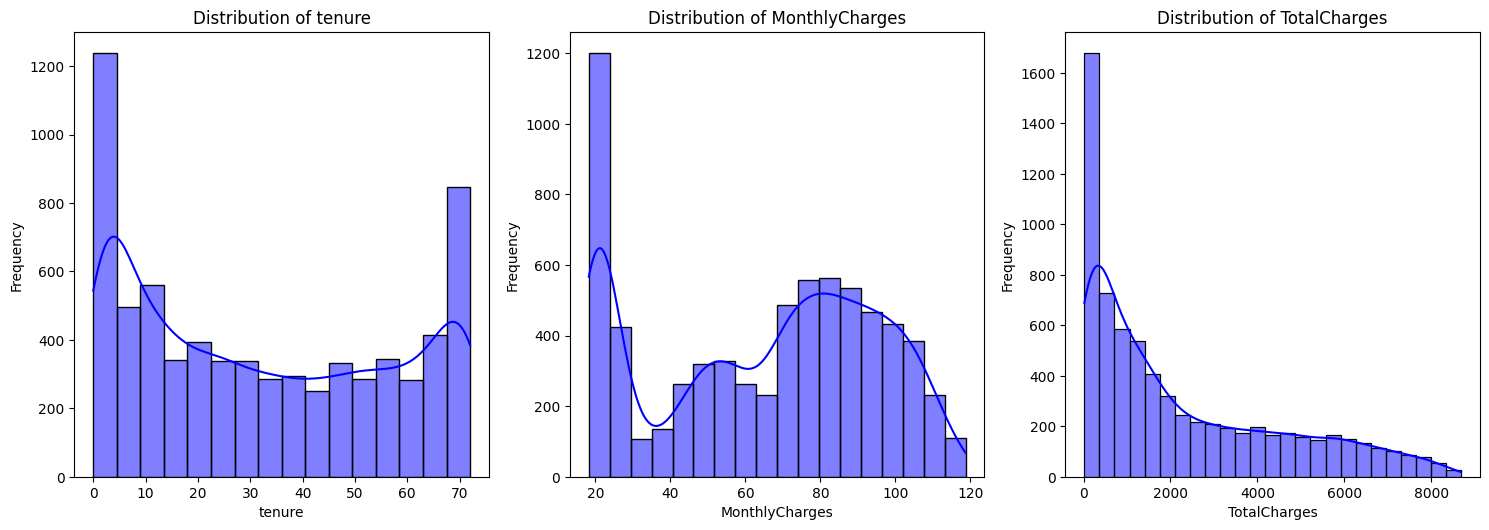

In [9]:
def plot_numeric_distributions(df):

    # select only numeric columns
    numeric_cols=df.select_dtypes(include=['number']).columns

    # Size of the plot grid
    num_cols=len(numeric_cols)
    num_rows=(num_cols // 3) + 1

    # create figure with subplots
    plt.figure(figsize=(15, 5*num_rows))

    # Loop through each numeric columns and create a distribution plot
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(num_rows,3,i)
        sns.histplot(df[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_numeric_distributions(df)

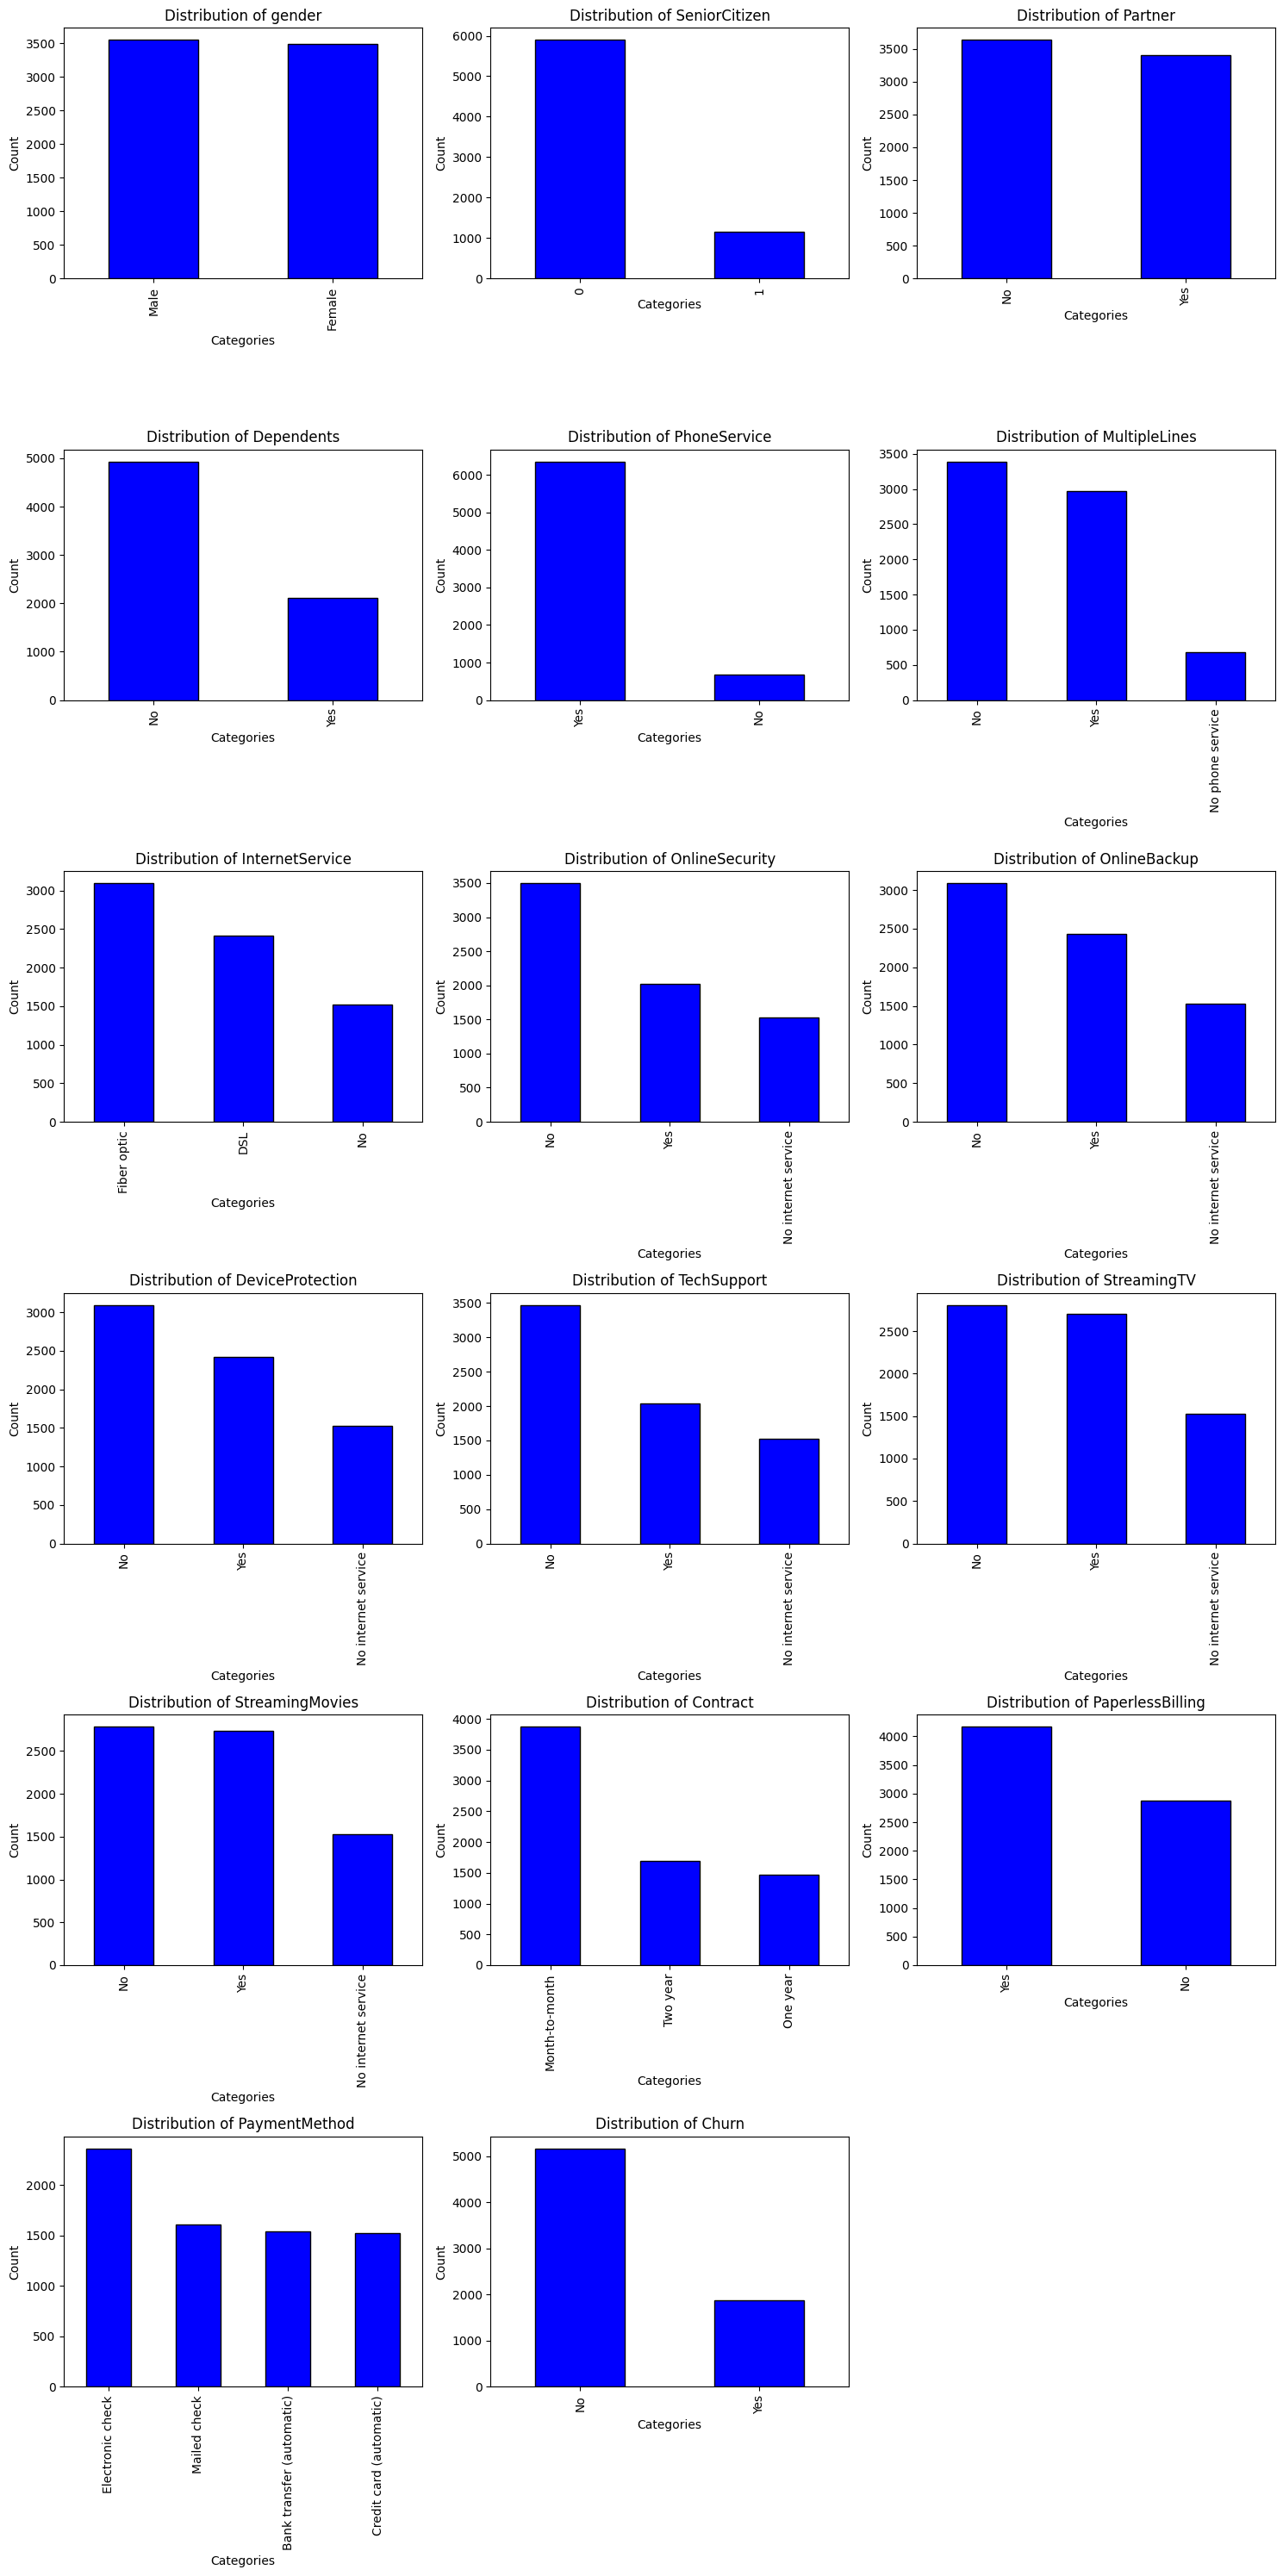

In [10]:
def plot_categorical(df, max_unique=20):
    # Select categorical columns with less than 20 unique value
    categorical_columns=[
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if df[col].nunique()<max_unique
    ]

    # Get the number of selected categorical column
    cat_columns=len(categorical_columns)
    if cat_columns == 0:
        print(f'No categorical columns with less than {max_unique} unique values.')
        return
    
    num_cols=min(3, cat_columns)
    num_rows=math.ceil(cat_columns / 3)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_columns):
        # Plot bar chart for each categorical columns
        df[col].value_counts().plot.bar(
            ax = axes[i],
            color = 'blue',
            edgecolor = 'black'
        )
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('Categories')
        axes[i].set_ylabel('Count')

    # Remove any extra subplots if the number of columns is not perfect multiple of 3
    for j in range(i+1,len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical(df, max_unique=20)

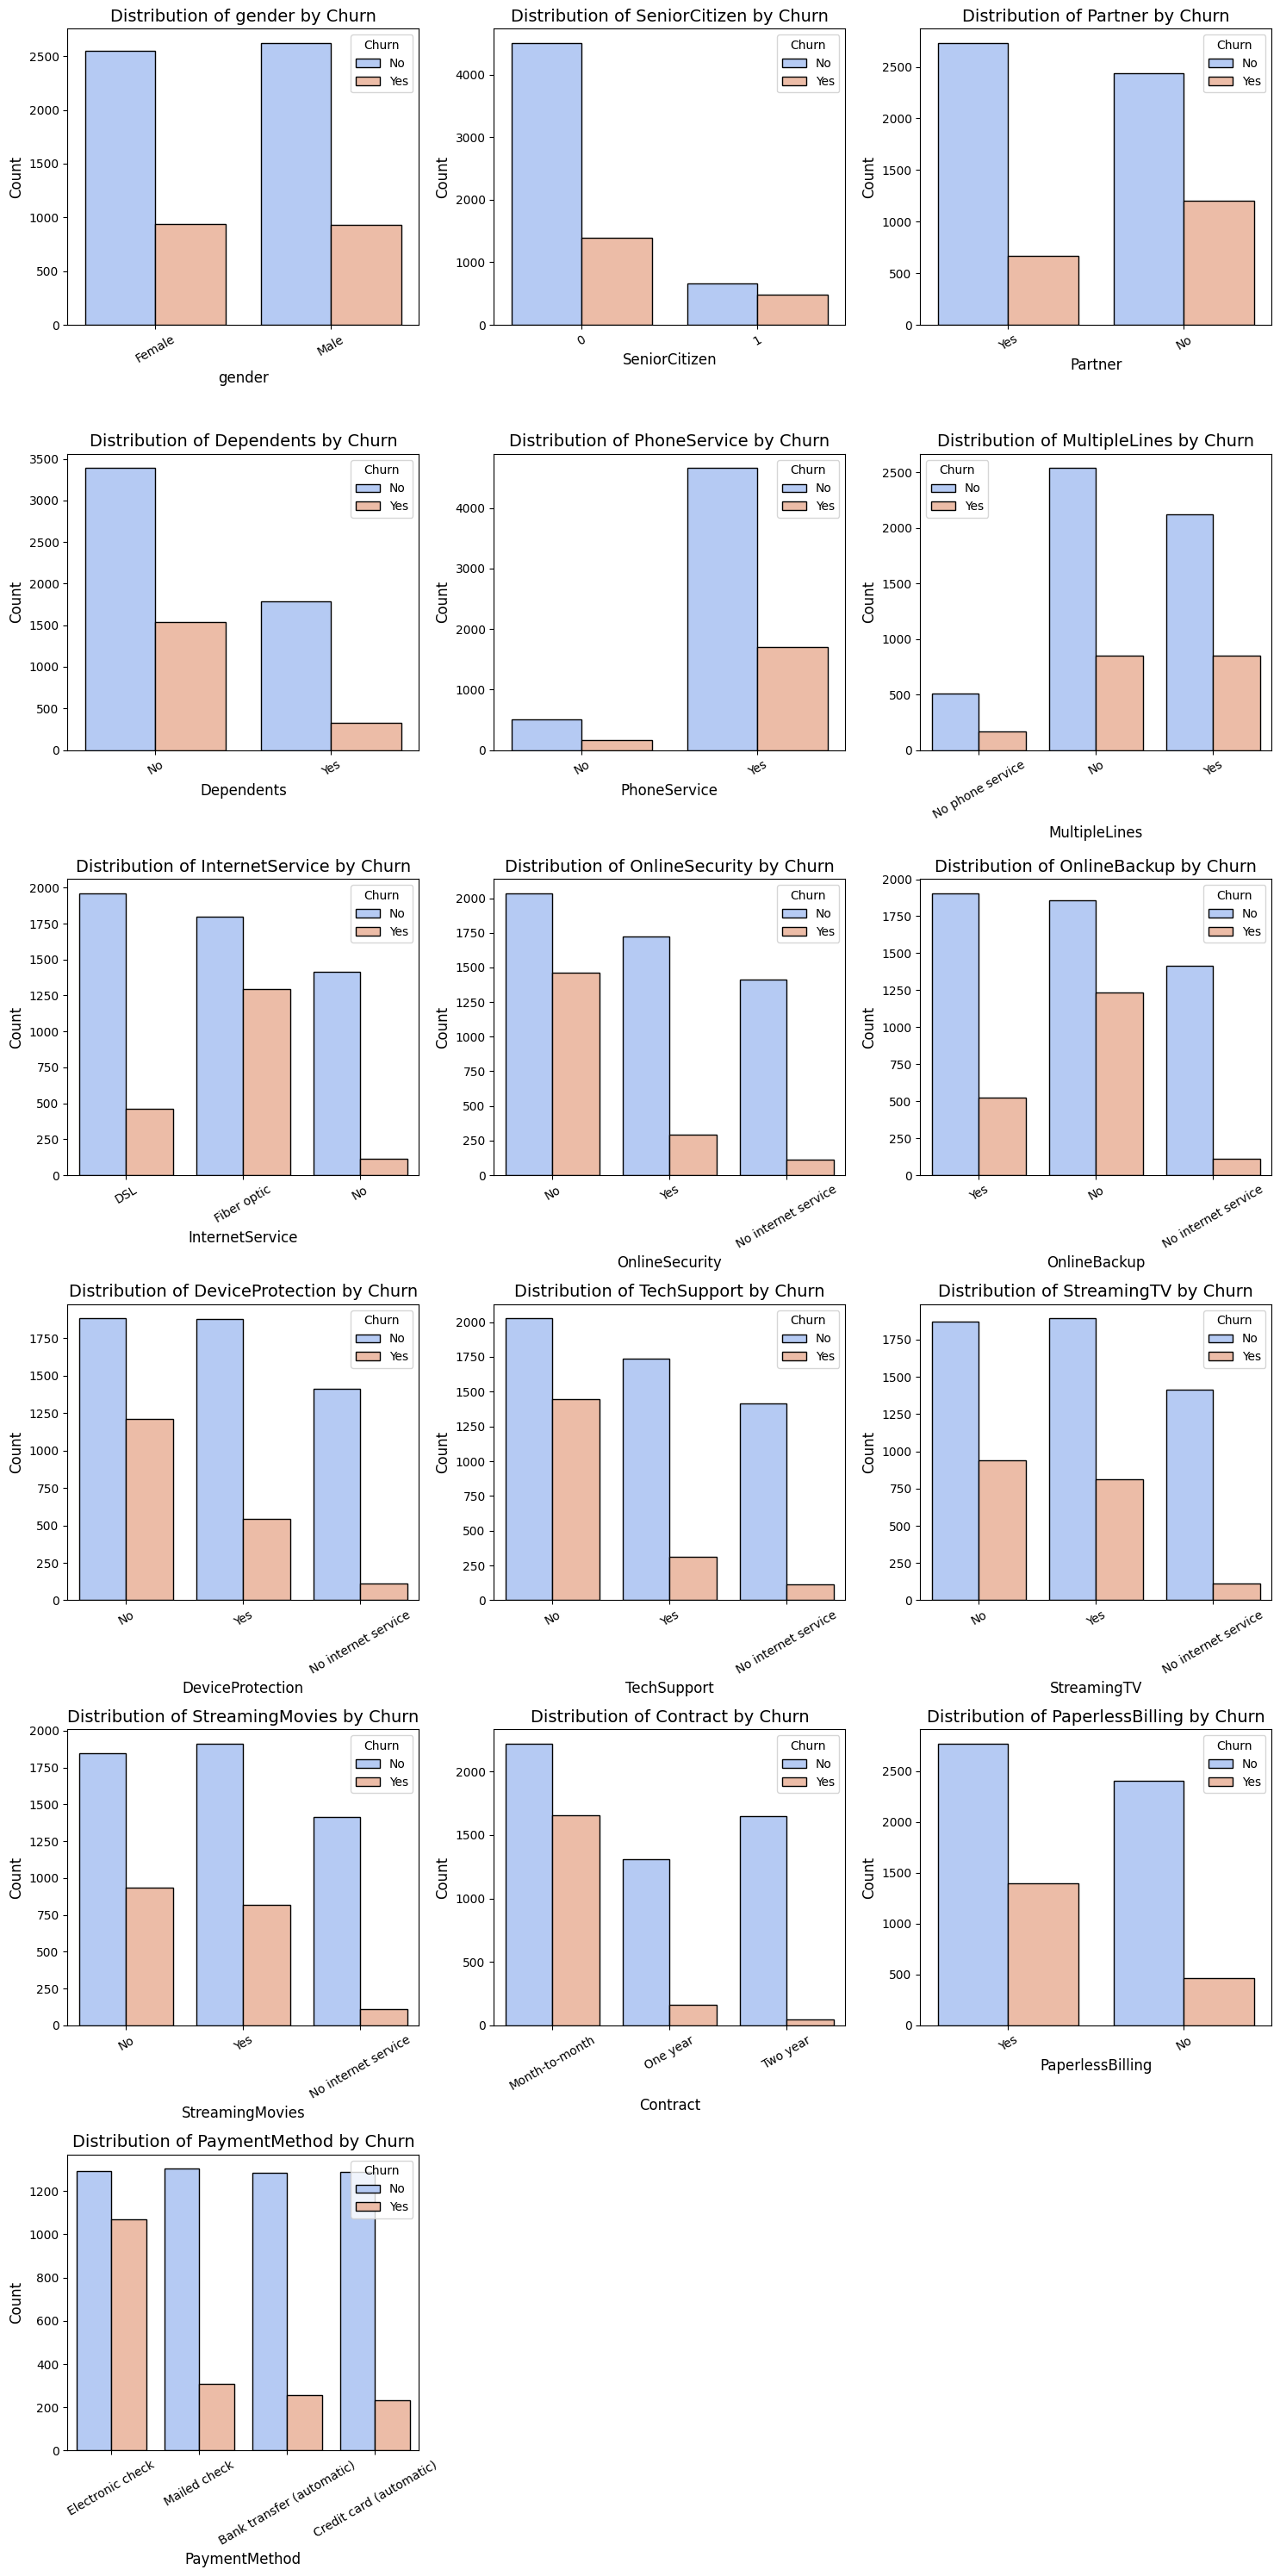

In [11]:
def plot_categorical(df, max_unique=20, hue_col='Churn'):
    # Select categorical columns with number of unique categories < max_unique
    categorical_columns = [
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if df[col].nunique() < max_unique and col != hue_col  # Exclude hue_col itself
    ]

    cat_columns = len(categorical_columns)
    if cat_columns == 0:
        print(f'No categorical columns with less than {max_unique} unique values.')
        return

    # Determine number of rows & columns for subplots
    num_cols = min(3, cat_columns)
    num_rows = math.ceil(cat_columns / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

    # Ensure axes is in list form (if only one plot)
    if cat_columns == 1:
        axes = [axes]

    axes = axes.flatten()  # Flatten if more than 1 plot

    for i, col in enumerate(categorical_columns):
        # Plot countplot with hue
        sns.countplot(
            x=col, hue=hue_col, data=df,
            ax=axes[i], palette="coolwarm", edgecolor="black"
        )
        axes[i].set_title(f'Distribution of {col} by {hue_col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)
        axes[i].tick_params(axis='x', rotation=30)  # Rotate x-axis labels for readability

    # Remove empty subplots if the number of categories is not a perfect fit
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Call the function
plot_categorical(df, max_unique=20, hue_col='Churn')


# **3️⃣ Data Preprocessing**
Step to **clean and standardize** the data:

- Drop Customer_ID
- Handling Missing Values
- Handling Outliers
- Convert categorical features into numerical values.

## Drop Customer_ID

In [12]:
df=df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Handling missing values

In [13]:
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


<Axes: xlabel='TotalCharges', ylabel='Count'>

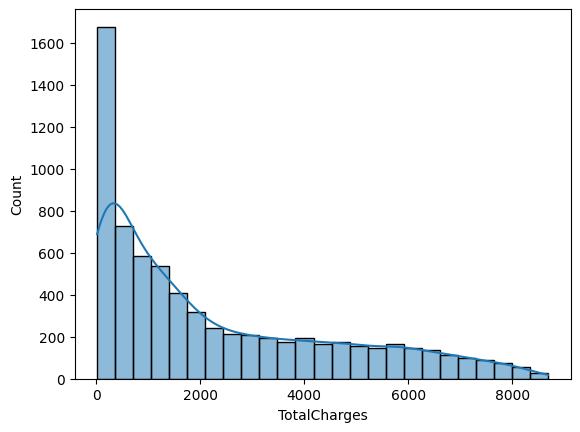

In [14]:
sns.histplot(data = df['TotalCharges'], kde = True)

In [15]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

## Handling outliers

C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2915178935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2915178935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2915178935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')


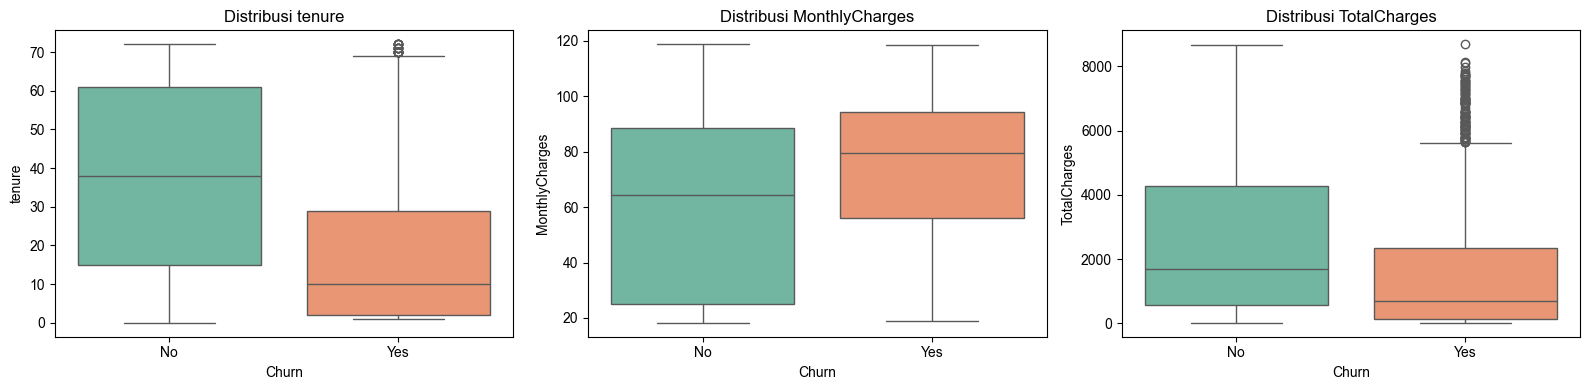

In [16]:
col = ['tenure','MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.set_style('darkgrid')

# Visualisasi distribusi per klasifikasi stroke
for ax, feature in zip(axes.flatten(), col):
    sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'Distribusi {feature}')
    ax.set_xlabel('Churn')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [17]:
def count_outliers(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count the number of outliers below the lower bound and above the upper bound
    num_outliers_below = (data[feature] < lower_bound).sum()
    num_outliers_above = (data[feature] > upper_bound).sum()

    print(f"{feature}: Lower Bound = {lower_bound}, Upper Bound = {upper_bound}, "
          f"Outliers below = {num_outliers_below}, Outliers above = {num_outliers_above}")

# Attributes with continuous data
col = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Count outliers before Winsorizing for each churn class
for label in df['Churn'].unique():
    class_data = df[df['Churn'] == label]
    print(f"\nChurn Category = {label}")
    for feature in col:
        count_outliers(class_data, feature)



Churn Category = No
tenure: Lower Bound = -54.0, Upper Bound = 130.0, Outliers below = 0, Outliers above = 0
MonthlyCharges: Lower Bound = -69.85, Upper Bound = 183.35000000000002, Outliers below = 0, Outliers above = 0
TotalCharges: Lower Bound = -4945.3375, Upper Bound = 9787.762499999999, Outliers below = 0, Outliers above = 0

Churn Category = Yes
tenure: Lower Bound = -38.5, Upper Bound = 69.5, Outliers below = 0, Outliers above = 23
MonthlyCharges: Lower Bound = -0.9250000000000043, Upper Bound = 151.275, Outliers below = 0, Outliers above = 0
TotalCharges: Lower Bound = -3160.7000000000003, Upper Bound = 5626.5, Outliers below = 0, Outliers above = 109


In [18]:
def winsorize_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Substitute outliers with the lower or upper bound
    data[feature] = data[feature].clip(lower=lower_bound, upper=upper_bound)
    return data

# Attributes with continuous data
col = ['tenure', 'TotalCharges']

# Apply Winsorizing for each churn class separately
winsorized_data = pd.DataFrame()
for label in df['Churn'].unique():
    class_data = df[df['Churn'] == label].copy()
    for feature in col:
        class_data = winsorize_iqr(class_data, feature)
    winsorized_data = pd.concat([winsorized_data, class_data], axis=0)

# Reset index on the final winsorized dataset
winsorized_data.reset_index(drop=True, inplace=True)

# Replace the original dataframe with the winsorized version
df = winsorized_data
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
3,Male,0,No,Yes,22.0,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
4,Female,0,No,No,10.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,No,No,12.0,Yes,No,DSL,No,No,No,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes
7039,Female,0,No,No,9.0,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes
7040,Male,1,No,No,1.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes
7041,Female,0,No,No,67.0,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,5626.50,Yes


C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2192315712.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2192315712.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
C:\Users\MANISH SAINI\AppData\Local\Temp\ipykernel_6164\2192315712.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')


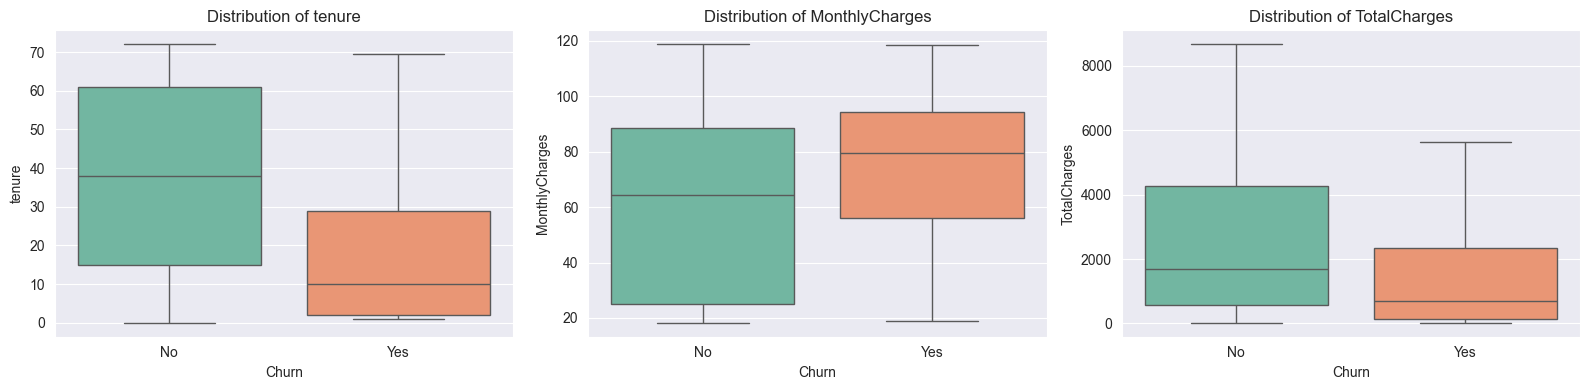

In [19]:
col = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.set_style('darkgrid')

# Visualize the distribution per Churn classification
for ax, feature in zip(axes.flatten(), col):
    sns.boxplot(data=df, x='Churn', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel('Churn')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


In [20]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
label_encoder = LabelEncoder()
for col in label_cols:
    label_encoder.fit(df[col])
    df[col] = label_encoder.transform(df[col])
    col = {index : label for index, label in enumerate(label_encoder.classes_)}
    print(col)

{0: 'Female', 1: 'Male'}
{0: '0', 1: '1'}
{0: 'No', 1: 'Yes'}
{0: 'No', 1: 'Yes'}
{0: 'No', 1: 'Yes'}
{0: 'No', 1: 'No phone service', 2: 'Yes'}
{0: 'DSL', 1: 'Fiber optic', 2: 'No'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'No', 1: 'No internet service', 2: 'Yes'}
{0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
{0: 'No', 1: 'Yes'}
{0: 'Bank transfer (automatic)', 1: 'Credit card (automatic)', 2: 'Electronic check', 3: 'Mailed check'}
{0: 'No', 1: 'Yes'}


In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
3,1,0,0,1,22.0,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,0
4,0,0,0,0,10.0,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,0


In [23]:
df.to_csv("EDA_and_Cleaning.csv", index=False)

----------